In [ ]:
# Imports and setup
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import SimpleITK as sitk
from PIL import Image
import matplotlib.pyplot as plt

import utils
from models import vit_base
from models.unetr_head import Unetr_Head
from dataset import SegImgs
from evaluation.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

In [ ]:
# Configuration
CHECKPOINT_HEAD = "/storage1/fs1/linyingz/Active/xiaoyus/VisionFM/evaluation/results/oct_seg_e100_metrics_fold_0/checkpoint_76_linear.pth"
ENCODER_WEIGHTS = "/storage1/fs1/linyingz/Active/xiaoyus/VisionFM/VFM_OCT_weights.pth"
DATA_ROOT       = "/storage1/fs1/linyingz/Active/xiaoyus/VisionFM/evaluation/RetouchData"
PRED_ROOT       = "/storage1/fs1/linyingz/Active/xiaoyus/VisionFM/evaluation/results/oct_seg_e100_metrics_fold_0/preds"
SPLIT_JSON     = "/storage1/fs1/linyingz/Active/xiaoyus/VisionFM/evaluation/retouch_splitted.json"
INPUT_SIZE      = 512
PATCH_SIZE      = 16
NUM_LABELS      = 4
BATCH_SIZE      = 64
NUM_WORKERS     = 0
MODALITY        = "OCT"
CHECKPOINT_KEY  = "teacher"
GRAY_LEVELS     = np.array([0, 85, 170, 255], dtype=np.uint8)

for split in ("training", "test"):
    os.makedirs(os.path.join(PRED_ROOT, split), exist_ok=True)


In [ ]:
# Encoder
encoder = vit_base(
    img_size=[INPUT_SIZE],
    patch_size=PATCH_SIZE,
    num_classes=0,
    use_mean_pooling=False
)
utils.load_pretrained_weights(
    encoder, ENCODER_WEIGHTS, CHECKPOINT_KEY, "vit_base", PATCH_SIZE
)
encoder.cuda().eval()

# Decoder
decoder = Unetr_Head(
    embed_dim=encoder.embed_dim,
    num_classes=NUM_LABELS,
    img_dim=INPUT_SIZE
)
ckpt = torch.load(CHECKPOINT_HEAD, map_location="cpu")
sd = {k.replace("module.",""): v for k, v in ckpt["state_dict"].items()}
decoder.load_state_dict(sd)
decoder.cuda().eval()

Take key teacher in provided checkpoint dict
will reisze the pos_embed from torch.Size([1, 197, 768]) to torch.Size([1, 1025, 768])
Pretrained weights found at /storage1/fs1/linyingz/Active/xiaoyus/VisionFM/VFM_OCT_weights.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v', 'head.last_layer2.weight_g', 'head.last_layer2.weight_v'])
base channel: 32


Unetr_Head(
  (dropout): Dropout2d(p=0.3, inplace=False)
  (d1): DeconvBlock(
    (deconv): ConvTranspose2d(768, 128, kernel_size=(2, 2), stride=(2, 2))
  )
  (s1): Sequential(
    (0): DeconvBlock(
      (deconv): ConvTranspose2d(768, 128, kernel_size=(2, 2), stride=(2, 2))
    )
    (1): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
  )
  (c1): Sequential(
    (0): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(12

In [ ]:
# Validation & Inference for fold 0 
FOLD = 0
print(f"\n=== Processing FOLD {FOLD} ===")

# Raw image transform
mean, std = utils.get_stats(MODALITY)
val_tf = Compose([
    Resize((INPUT_SIZE, INPUT_SIZE)),
    ToTensor(),
    Normalize(mean, std),
])

def joint_tf(img, label):
    img_t   = val_tf(img)                         # Tensor [C,H,W]
    label_t = torch.from_numpy(np.array(label))   # Tensor [H,W]
    return img_t, label_t

# Create loaders for both splits
dataloaders = {}
for split in ("training", "test"):
    ds = SegImgs(
        root=DATA_ROOT,
        split=split,
        transform=joint_tf,
        split_file= SPLIT_JSON,
        fold=FOLD,
    )
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    print(f">>> {split} has {len(ds)} samples")
    dataloaders[split] = loader

# Run inference & save masks
with torch.no_grad():
    for split, loader in dataloaders.items():
        for inp, _, extras in tqdm(loader, desc=f"Inference {split}", leave=False):
            inp = inp.cuda(non_blocking=True)            

            n      = len(encoder.blocks)
            inter  = encoder.get_intermediate_layers(inp, n)
            levels = [3,5,7,11] if n==12 else [5,11,17,23]
            feats  = [inter[i][:,1:] for i in levels]

            # predict
            logits  = decoder(feats, inp)              
            mask_id = torch.argmax(logits, dim=1)      
            mask_np = mask_id.cpu().numpy().astype(np.uint8)
            vis_mask = GRAY_LEVELS[mask_np]            

            # save each item in the batch
            for i in range(vis_mask.shape[0]):
                fname      = os.path.basename(extras['img_path'][i])
                out_folder = os.path.join(PRED_ROOT, split)
                os.makedirs(out_folder, exist_ok=True)
                out_path   = os.path.join(out_folder, fname)
                Image.fromarray(vis_mask[i]).save(out_path)



=== Processing FOLD 0 ===
[SegImgs] loaded 2832 image/mask pairs from fold=0, split=train
[SegImgs] using 1 augmentations per image
>>> training has 2832 samples
[SegImgs] loaded 1416 image/mask pairs from fold=0, split=val
[SegImgs] using 1 augmentations per image
>>> test has 1416 samples


[SegImgs] loaded 2832 image/mask pairs from fold=0, split=train
[SegImgs] using 1 augmentations per image
[SegImgs] loaded 1416 image/mask pairs from fold=0, split=val
[SegImgs] using 1 augmentations per image


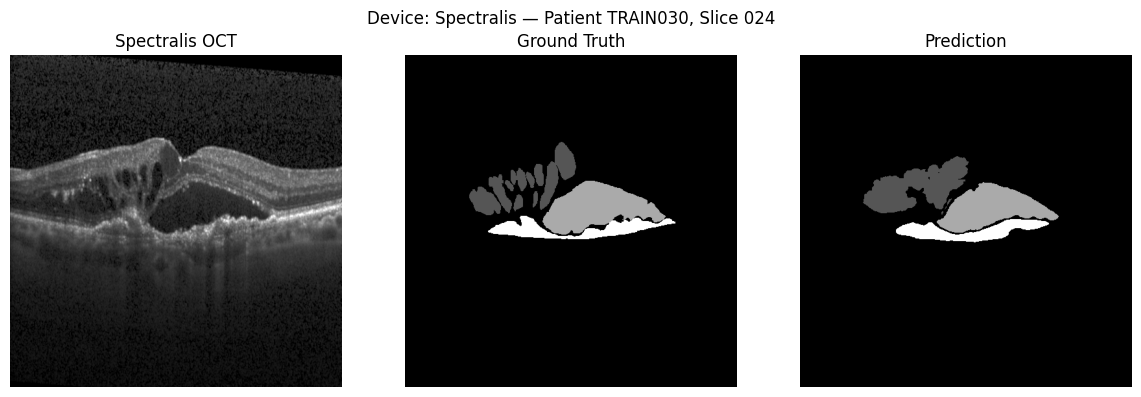

In [ ]:
# Example visualization
# Target specification
TARGET_DEVICE  = "Spectralis"
TARGET_PATIENT = "TRAIN030"
TARGET_SLICE   = "024"

# Scan both splits until target found
for TARGET_SPLIT in ("training", "test"):
    ds_test = SegImgs(
        root=DATA_ROOT,
        split=TARGET_SPLIT,
        transform=lambda i, l: (i, l),
        split_file=SPLIT_JSON,
        fold=FOLD,
    )
    try:
        idx = next(
            i for i, (_, _, ex) in enumerate(ds_test)
            if TARGET_DEVICE in ex["img_path"] and f"{TARGET_PATIENT}_oct_{TARGET_SLICE}" in ex["img_path"]
        )
        break
    except StopIteration:
        continue
else:
    raise ValueError("Sample not found in either split")

# Find the index of the example by scanning ds_test
target_fname = f"{TARGET_PATIENT}_oct_{TARGET_SLICE}.png"
idx = None
for i, (_, _, extras) in enumerate(ds_test):
    path = extras["img_path"]
    if TARGET_DEVICE in path and target_fname in path:
        idx = i
        break
if idx is None:
    raise ValueError(f"Sample {TARGET_DEVICE}/{TARGET_PATIENT}/{TARGET_SLICE} not found in fold {FOLD}")

_, gt, extras = ds_test[idx]
raw_path     = extras["img_path"]

# Resize & load all three images
raw = Image.open(raw_path).convert("L")
raw = raw.resize((INPUT_SIZE, INPUT_SIZE), Image.BILINEAR)
raw_arr = np.array(raw, dtype=np.uint8)

gt_resized = gt.resize((INPUT_SIZE, INPUT_SIZE), Image.NEAREST)
gt_vis     = np.array(gt_resized, dtype=np.uint8)

pred_fname = os.path.basename(raw_path)
pred_path  = os.path.join(PRED_ROOT, TARGET_SPLIT, pred_fname)
pr         = Image.open(pred_path).convert("L")
pr         = pr.resize((INPUT_SIZE, INPUT_SIZE), Image.NEAREST)
pr_arr     = np.array(pr, dtype=np.uint8)
if pr_arr.max() <= len(GRAY_LEVELS)-1:
    pr_vis = np.vectorize(lambda x: GRAY_LEVELS[x])(pr_arr).astype(np.uint8)
else:
    pr_vis = pr_arr

# plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(raw_arr, cmap="gray");    axes[0].set_title("Spectralis OCT")
axes[1].imshow(gt_vis,  cmap="gray");    axes[1].set_title("Ground Truth")
axes[2].imshow(pr_vis,  cmap="gray");    axes[2].set_title("Prediction")
for ax in axes:
    ax.axis("off")
plt.suptitle(f"Device: {TARGET_DEVICE} — Patient {TARGET_PATIENT}, Slice {TARGET_SLICE}")
plt.tight_layout()    
plt.show()

[SegImgs] loaded 2832 image/mask pairs from fold=0, split=train
[SegImgs] using 1 augmentations per image


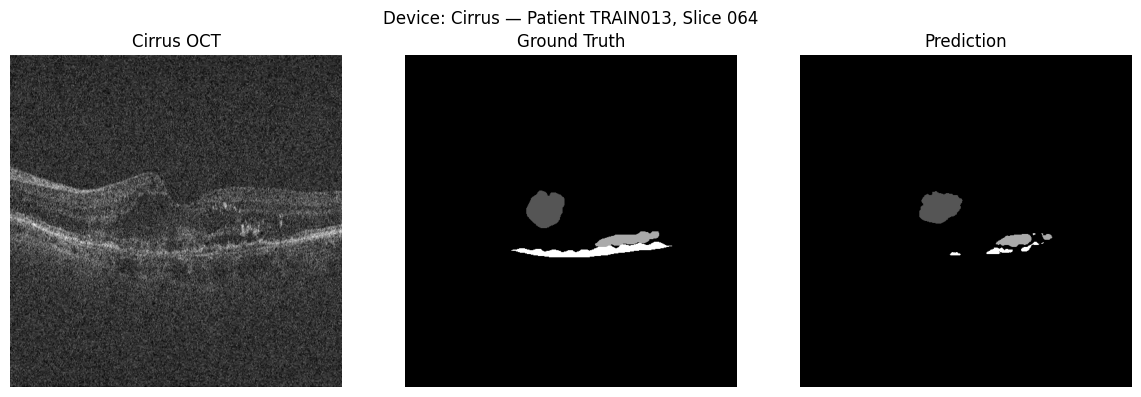

In [ ]:
# Example visualization
# Target specification
TARGET_DEVICE  = "Cirrus"
TARGET_PATIENT = "TRAIN013"
TARGET_SLICE   = "064"

# Scan both splits until target found
for TARGET_SPLIT in ("training", "test"):
    ds_test = SegImgs(
        root=DATA_ROOT,
        split=TARGET_SPLIT,
        transform=lambda i, l: (i, l),
        split_file=SPLIT_JSON,
        fold=FOLD,
    )
    try:
        idx = next(
            i for i, (_, _, ex) in enumerate(ds_test)
            if TARGET_DEVICE in ex["img_path"] and f"{TARGET_PATIENT}_oct_{TARGET_SLICE}" in ex["img_path"]
        )
        break
    except StopIteration:
        continue
else:
    raise ValueError("Sample not found in either split")

# Find the index of the example by scanning ds_test
target_fname = f"{TARGET_PATIENT}_oct_{TARGET_SLICE}.png"
idx = None
for i, (_, _, extras) in enumerate(ds_test):
    path = extras["img_path"]
    if TARGET_DEVICE in path and target_fname in path:
        idx = i
        break
if idx is None:
    raise ValueError(f"Sample {TARGET_DEVICE}/{TARGET_PATIENT}/{TARGET_SLICE} not found in fold {FOLD}")

_, gt, extras = ds_test[idx]
raw_path     = extras["img_path"]

# Resize & load all three images
raw = Image.open(raw_path).convert("L")
raw = raw.resize((INPUT_SIZE, INPUT_SIZE), Image.BILINEAR)
raw_arr = np.array(raw, dtype=np.uint8)

gt_resized = gt.resize((INPUT_SIZE, INPUT_SIZE), Image.NEAREST)
gt_vis     = np.array(gt_resized, dtype=np.uint8)

pred_fname = os.path.basename(raw_path)
pred_path  = os.path.join(PRED_ROOT, TARGET_SPLIT, pred_fname)
pr         = Image.open(pred_path).convert("L")
pr         = pr.resize((INPUT_SIZE, INPUT_SIZE), Image.NEAREST)
pr_arr     = np.array(pr, dtype=np.uint8)
if pr_arr.max() <= len(GRAY_LEVELS)-1:
    pr_vis = np.vectorize(lambda x: GRAY_LEVELS[x])(pr_arr).astype(np.uint8)
else:
    pr_vis = pr_arr

# plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(raw_arr, cmap="gray");    axes[0].set_title("Spectralis OCT")
axes[1].imshow(gt_vis,  cmap="gray");    axes[1].set_title("Ground Truth")
axes[2].imshow(pr_vis,  cmap="gray");    axes[2].set_title("Prediction")
for ax in axes:
    ax.axis("off")
plt.suptitle(f"Device: {TARGET_DEVICE} — Patient {TARGET_PATIENT}, Slice {TARGET_SLICE}")
plt.tight_layout()    
plt.show()